# ПЛАН А/В ТЕСТИРОВАНИЯ **"Обновление дизайна сайта"**
1. Бизнес проблема. Решаемая задача: **Обновить дизайн сайт. Сделать сайт более удобным и современным**

2. Гипотеза: **Изменение дизайна сайта приведет к увеличению выручки**. 
- что мы изменим - **дизайн сайта**;
- на что это повлияет - **увеличение выручки**;
- как будем измерять (**средняя выручка с клиента**).

3. Уровни ошибок и ожидаемый эффект:
- допустимый уровень ошибки первого рода - **0.05**;
- допустимый уровень ошибки второго рода - **0.1**;
- минимальный детектируемый эффект (**MDE - 5% от среднего**).

4. Оценка продолжительности эксперимента: **с 2022-03-23 по 2022-03-30**.

5. Проверка дизайна на исторических данных:
- A/A эксперименты на исторических данных;
- A/B эксперименты на исторических данных (с добавлением эффекта, равного по величине MDE).

6. Критерий принятия финального решения: **t-test**.

In [404]:
# импорт основных библиотек
# библиотеки для анализа данных
import pandas as pd
import numpy as np
# статистика
from scipy import stats
from scipy.stats import norm, ttest_ind, mannwhitneyu #ttest_ind от independent - для независимых выборок
# графики
import matplotlib.pyplot as plt
import seaborn as sns
# дата, время
from datetime import datetime
import time
# вз/действие кода с опер.системой
import os
# зерно для случайного распределения
np.random.seed(23)

# Доступ к сырым данным

In [405]:
# импорт данных для анализа из таблицы, которая в одной папке с ноутбуком на локаотном компе
# df_sales = pd.read_csv('df_sales.csv') #продажи

# вариант подключения с репозитория GitHub
URL_BASE = 'https://raw.githubusercontent.com/Kiv75355/Krivoschekova/refs/heads/main/AB-testing/'

# процедура для извлечения файла из репозитория
def read_database(file_name):
    return pd.read_csv(os.path.join(URL_BASE, file_name))

In [406]:
# извлекаем
df_sales = read_database('df_sales.csv')
df_users = read_database('df_users.csv')

In [407]:
# столбец date переведем из формата str в формат datetime
df_sales['date'] = pd.to_datetime(df_sales['date'])
df_sales.head(3)

,sale_id,date,count_pizza,count_drink,price,user_id
0,1000001,2022-02-04 10:00:24,1,0,720,1c1543
1,1000002,2022-02-04 10:02:28,1,1,930,a9a6e8
2,1000003,2022-02-04 10:02:35,3,1,1980,23420a


In [408]:
df_users.head(3)

,user_id,pilot
0,0ffc65,0
1,b962b9,0
2,7ea63f,0


# АА-тест. Отличия до эксперимента

Перед проведением теста проверим, что пилотная и контрольная группы были сопоставимы до эксперимента. Для этого проведем АА-тест.

In [409]:
# считаем значение метрики: берем выручку за неделю до эксперимента и группируем по клиенту
pre_df_mertics = (df_sales[(df_sales['date'] >= datetime(2022, 3, 16)) 
               & (df_sales['date'] < datetime(2022, 3, 23))]
                .groupby('user_id')[['price']].sum()
                .reset_index()  
                )

In [410]:
# добавляем данные о разбиении на пилотную и контрольную группы 
# если клиент из выборки не совершал покупки - заполняем по нему данные 0
pre_df = pd.merge(df_users,
              pre_df_mertics,
              how = 'left',
              on = 'user_id').fillna(0)

In [411]:
# создаем 2 датасета: пилот и контроль
pre_df_control = pre_df[pre_df['pilot'] == 0]['price'] 
pre_df_pilot = pre_df[pre_df['pilot'] == 1]['price']

# проконтролируем размеры этих групп
print('Группа-контоль содержит', len(pre_df_control), 'записей.')
print('Группа-пилот содержит', len(pre_df_pilot), 'записей.')

Группа-контоль содержит 11769 записей.
Группа-пилот содержит 11564 записей.


In [412]:
stats.ttest_ind(pre_df_control, pre_df_pilot)

Ttest_indResult(statistic=-1.2837567415000515, pvalue=0.19923983306424942)

Получили p-value = 0.199. При заданном alpha = 0,05 имеем p-value > alpha.


**Вывод:** 
- На уровне значимости 0.05 гипотеза о равенстве средних подтверждается.
- Группы статистически значимо не отличаются до эксперимента, что дает нам право проводить AB-тест.

# Оценка вероятностей ошибок 1 и 2 рода. Тестирование дизайна

Проверить правильность дизайна эксперимента можно с помощью синтетических (моделируемых) экспериментов на исторических данных.

**Для ошибки 1 рода**: можно запустить 1000 экспериментов на исторических данных. Мы знаем, что эффекта там не должно быть - т.к. там не было изменений. Поэтому доля экспериментов, в которых будет обнаружен значимый эффект - это оценка вероятности ошибки 1 рода. Это АА-тест.

**Для ошибки 2 рода**: можно также на исторических данных запустить 1000 экспериментов. При этом в пилотную группу искусственно добавить эффект равный mde. Далее оценить согласно дизайну - долю экспериментов, в которых значимые отличия не были найдены - это оценка вероятности ошибки 2 рода.

**Распределение pvalue**: надо построить графики распределения pvalue для синтетических АА и АВ тестов. Для АА-тестов pvalue должен быть распределен равномерно (~диагональ). Если график отклоняется - значит в дизайне ошибка (пересмотреть сроки, разбиение на группы, зависимые данные в выборках). Для АВ-тестов распределние pvalue д.б. выпуклым вверх (чем более выпуклый, тем лучше). 

In [413]:
# построим ECDF — это Эмпирическая Функция Распределения для pvalue
def plot_pvalue_ecdf(pvalues):
    sns.ecdfplot(pvalues)
    plt.plot([0,1],[0,1],'k--') # k-- это стиль линии (черный пунктир)
    plt.xlabel('p-value')
    plt.ylabel('Probability')
    plt.show()

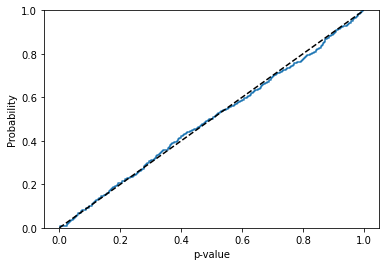

In [414]:
# берем датасет pre_df - в нем предэкспериментальный период, там нет эффекта
p_values = []
users = pre_df['user_id'].unique()

for _ in range(500):
    np.random.shuffle(users) # перемешаем юзеров, чтобы каждый цикл они распределялись по разному
    group_a, group_b = users[:len(users) // 2], users[len(users) // 2:]
    sales_a = pre_df[pre_df['user_id'].isin(group_a)]['price']
    sales_b = pre_df[pre_df['user_id'].isin(group_b)]['price']
    _, p_val = ttest_ind(sales_a, sales_b)
    p_values.append(p_val)

# отстроим график    
plot_pvalue_ecdf(p_values)

Видим, что мы конролируем ошибку 1 рода, т.к. при АА-тесте pvalue распределено равномерно.

Теперь оценим вероятность ошибки 2 рода. Для этого надо многократно провести АВ-тестирование (для группы В добавим mde).

Многократно запустим АВ-тест на данных перед экспериментом, добавляя к группе_В заявленный mde.

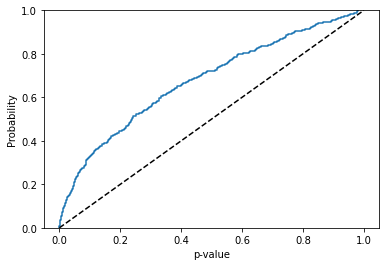

In [415]:
p_values = []
users = pre_df['user_id'].unique()
mde_ = 1.05

for _ in range(500):
    np.random.shuffle(users)
    group_a, group_b = users[:len(users) // 2], users[len(users) // 2:]
    sales_a = pre_df[pre_df['user_id'].isin(group_a)]['price']
    sales_b = pre_df[pre_df['user_id'].isin(group_b)]['price']
    sales_b *= mde_
    _, p_val = ttest_ind(sales_a, sales_b) 
    p_values.append(p_val)

# отстроим график     
plot_pvalue_ecdf(p_values)

На уровне значимости 0.05 мы отлавливаем эффект в среднем в 80-ти случаях из 100, то есть тест обладает заданной мощностью и дизайн полностью корректен.

То есть если мы будем проводить тест на уровне значимости 0.05, то вероятность ошибки 1-го рода в действительности равняется 0.05. Более того, мы обнаружим эффект равный  𝑀𝐷𝐸 в среднем в 80-ти случаях из 100, если он на самом деле присутствует, что мы и закладывали в дизайне эксперимента.

# Вычисление метрики для эксперимента

In [416]:
# считаем значение метрики: берем выручку за указанный период и суммируем по клиенту
df_mertics = (df_sales[(df_sales['date'] >= datetime(2022, 3, 23)) 
                     & (df_sales['date'] < datetime(2022, 3, 30))]
            .groupby('user_id')[['price']].sum()
            .reset_index()  
            )
df_mertics.head(3)

,user_id,price
0,0000d4,720
1,0000de,660
2,0000e4,840


In [417]:
# добавляем данные о разбиении на пилотную и контрольную группы 
# если клиент из выборки не совершал покупки - заполняем по нему данные 0
df = pd.merge(df_users,
              df_mertics,
              how = 'left',
              on = 'user_id').fillna(0)
df.head(3)

,user_id,pilot,price
0,0ffc65,0,0.0
1,b962b9,0,840.0
2,7ea63f,0,0.0


In [418]:
# создаем 2 датасета: пилот и контроль
df_control = df[df['pilot'] == 0]['price'] 
df_pilot = df[df['pilot'] == 1]['price']

# проконтролируем размеры этих групп
print('Группа-контоль содержит', len(df_control), 'записей.')
print('Группа-пилот содержит', len(df_pilot), 'записей.')

Группа-контоль содержит 11769 записей.
Группа-пилот содержит 11564 записей.


Проверим достататочен ли размер наших выборок для отлавливания эффекта в 5% при заданных условиях (альфа = 0,05, бета = 0,1).

# Размер выборки

Формула расчета размера выборки:

$$n > \dfrac{\left[ \Phi^{-1} \Bigl( 1-\dfrac{\alpha}{2} \Bigr) + \Phi^{-1} \Bigl( 1-\beta \Bigr) \right]^2 (\sigma_X^2 + \sigma_Y^2)}{\varepsilon^2}$$

Реализуем эту формулу для случая равных дисперсий ввиде 2х функций:

In [419]:
# для случая, когда эффект выражен в абсолюте
def get_sample_size_abs(epsilon, std, alpha=0.05, beta=0.1): # здесь epsilon - эффект
    a = norm.ppf(1 - alpha / 2, loc=0, scale=1)  # здесь loc среднее, scale станд.откл.
    b = norm.ppf(1 - beta, loc=0, scale=1)
    sample_size = int((a + b) ** 2 * (2 * std ** 2) / (epsilon ** 2))
    return sample_size

# для случая, когда эффект выражен в относительной величине
def get_sample_size_rel(m, std, eff=1.05, alpha=0.05, beta=0.1):
    epsilon = (eff - 1) * m  # здесь m - это среднее
    return get_sample_size_abs(epsilon, std=std, alpha=alpha, beta=beta)

In [420]:
# посчитаем оптимальный размер выборки на исторических данных (неделя до эксперимента)
pre_m = pre_df['price'].mean()
pre_std = pre_df['price'].std()

n = get_sample_size_rel(pre_m, pre_std, eff=1.05, alpha=0.05, beta=0.1)
print('Оптимальный размер выборки равен', n)

Оптимальный размер выборки равен 90427


Видим, что оптимальный размер выборки сильно больше, чем то, что у нас есть (90000 против 11500) - из-за большой дисперсии данных и большого количества нулей. Поэтому нам необходимо пересмотреть MDE.

# MDE

Рассчитаем какой эффект мы способны поймать при выборке размером 11500.
Напишем функцию для оценки размера выборки:

$$\varepsilon > \frac{\left[ \Phi^{-1} \left( 1-\dfrac{\alpha}{2} \right) + \Phi^{-1} \left( 1-\beta \right) \right] \sqrt{ \sigma_X^2 + \sigma_Y^2 }}{\sqrt{n}}$$

Реализуем эту формулу для случая равных дисперсий:

In [421]:
def get_mde(std, sample_size, alpha=0.05, beta=0.2):
    a = norm.ppf(1 - alpha / 2, loc=0, scale=1)
    b = norm.ppf(1 - beta, loc=0, scale=1)
    disp_sum_sqrt = (2 * (std ** 2)) ** 0.5
    mde = (a + b) * disp_sum_sqrt / np.sqrt(sample_size)
    return mde

In [422]:
# какой эффект мы можем заметить, если задействуем всю нашу выборку
sample_size = 11500

mde = get_mde(pre_std, sample_size, alpha=0.05, beta=0.1)
print(f'Минимальный детектируемый эффект равен {mde/pre_m*100:.2f}%')

Минимальный детектируемый эффект равен 14.02%


С выборкой ~11500 мы сможем уловить эффект ~14%

# Многократный дизайн эксперимента

Зная среднее, отклонение, альфа, бета и mde мы также  можем провести многократный дизайн эксперимента на исторических данных.

#### Сначала проведем дизайн для базовых вводных: эффект 5%; альфа 0,05; бета 0,1; sample_size = 11500

In [423]:
m = pre_df['price'].mean()
std = pre_df['price'].std()
eff = 1.05
alpha = 0.05
beta = 0.1
sample_size = 11500


def check_ttest(a, b, alpha=0.05):
    """Тест Стьюдента. Возвращает 1, если отличия значимы."""
    _, pvalue = ttest_ind(a, b)
    return int(pvalue < alpha)

# оценим вероятности ошибок 1 и 2 рода
print('Ошибки I и II рода:')
for _ in range(5):
    result_aa = []
    result_ab = []
    for _ in range(5000):
        a_one = np.random.normal(m, std, sample_size)
        a_two = np.random.normal(m, std, sample_size)
        b = np.random.normal(m * eff, std, sample_size)
        result_aa.append(check_ttest(a_one, a_two, alpha=alpha))
        result_ab.append(check_ttest(a_one, b, alpha=alpha))
    error_first = np.mean(result_aa)
    error_second = 1 - np.mean(result_ab)
    print(f'  {error_first:0.3f} \t{error_second:0.3f}')

Ошибки I и II рода:
  0.049 	0.784
  0.049 	0.787
  0.052 	0.790
  0.050 	0.784
  0.051 	0.794


Результат симуляции на базовых вводных: ошибка II рода ≈ 0.79 (мощность ~21%). Это крайне мало.

#### Теперь проведем дизайн, изменив эффект: эффект 14%

In [424]:
m = pre_df['price'].mean()
std = pre_df['price'].std()
eff = 1.14
alpha = 0.05
beta = 0.1
sample_size = 11500


def check_ttest(a, b, alpha=0.05):
    """Тест Стьюдента. Возвращает 1, если отличия значимы."""
    _, pvalue = ttest_ind(a, b)
    return int(pvalue < alpha)

# оценим вероятности ошибок 1 и 2 рода
print('Ошибки I и II рода:')
for _ in range(5):
    result_aa = []
    result_ab = []
    for _ in range(5000):
        a_one = np.random.normal(m, std, sample_size)
        a_two = np.random.normal(m, std, sample_size)
        b = np.random.normal(m * eff, std, sample_size)
        result_aa.append(check_ttest(a_one, a_two, alpha=alpha))
        result_ab.append(check_ttest(a_one, b, alpha=alpha))
    error_first = np.mean(result_aa)
    error_second = 1 - np.mean(result_ab)
    print(f'  {error_first:0.3f} \t{error_second:0.3f}')

Ошибки I и II рода:
  0.050 	0.098
  0.053 	0.103
  0.049 	0.102
  0.048 	0.097
  0.047 	0.113


Результат: ошибка II рода ≈ 0.10 (мощность ~90%)

Вывод: 14% — это минимальный эффект, который мы можем обнаружить при sample_size = 11500, alpha = 0.05, beta = 0.1, дисперсии аналогичной данным за неделю до эксперимента.

Мы не можем заменить MDE, т.к. это поменяет базовый сценарий. Но мы будем понимать, что если реальный эффект меньше 14%, то мы его скорее всего НЕ заметим.

Переходим к АВ-тестированию по базовому сценарию.

Существет много **методов сравнения групп в A/B-тестировании**. Вот основные из них:
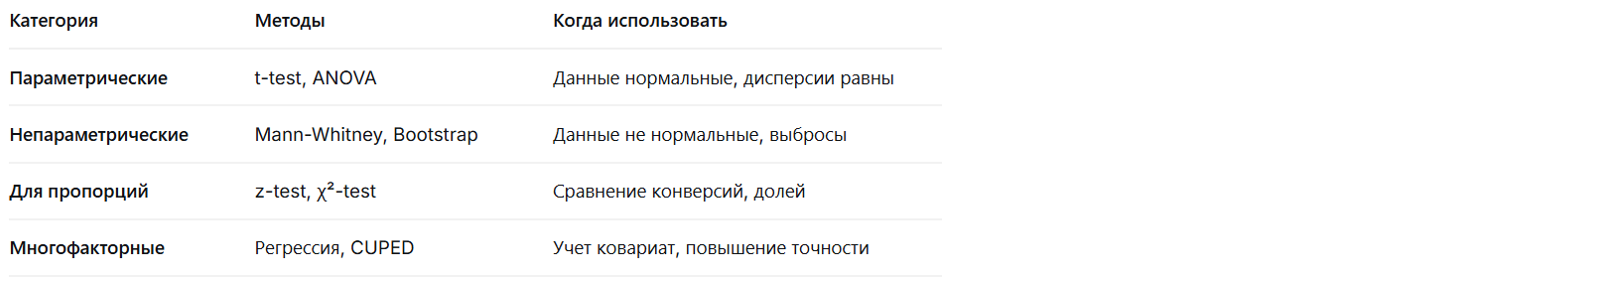

Будем использовать базовый ttest - как основной критерий. Тест Манна Уитни - как дополнительный критерий.

# T-test

t-тест — это статистический критерий, который проверяет, являются ли различия между средними значениями двух групп статистически значимыми.

H₀ (нулевая гипотеза): среднее в контроле = среднему в пилоте

H₁ (альтернативная): среднее в контроле не равно среднему в пилоте

In [434]:
stat, pvalue = stats.ttest_ind(df_control, df_pilot)

mean_control = df_control.mean()
mean_pilot = df_pilot.mean()
diff = mean_pilot - mean_control
rel_effect = (diff / mean_control) * 100

print(f"Среднее в контроле: {mean_control:.2f}")
print(f"Среднее в пилоте: {mean_pilot:.2f}")
print(f"Разница: {diff:.2f} ({rel_effect:.2f}%)")
print(f"p-value: {pvalue:.2e}")

Среднее в контроле: 861.97
Среднее в пилоте: 952.25
Разница: 90.29 (10.47%)
p-value: 6.41e-15


**Результат t-test:**

p-value = 6.41e-15, что значительно меньше уровня значимости α = 0.05. Статистически значимые различия обнаружены

Средняя выручка в пилотной группе: 952.25 руб.

Средняя выручка в контрольной группе: 861.97 руб.

Разница: +90.29 руб. Мы смогли обнаружить эффект +10.47% (хотя реальный MDE ~14%). Это говорит о том, что реальная дисперсия в эксперименте оказалась ниже, чем в исторических данных, либо эффект превысил наши ожидания.

**Вывод**:

Мы отвергаем нулевую гипотезу о равенстве средних. Пилотная группа показывает статистически значимое увеличение выручки. Эффект положительный: пилот работает в сторону улучшения метрики

# Тест Манна-Уитни

Наша метрика "выручка на пользователя" имеет скошенное распределение с множеством нулевых значений, t-тест может быть чувствителен к этому. Тест Манна-Уитни позволит проверить, является ли эффект (рост выручки) статистически значимым без предположения о нормальности данных, что сделает вывод более надежным.

Тест Манна-Уитни - это непараметрический критерий, который сравнивает две независимые выборки и проверяет, есть ли между ними систематическое смещение. Вместо самих значений он использует их ранги (порядковые номера), что делает его устойчивым к выбросам и ненормальному распределению.

H₀ (нулевая гипотеза): распределение выручки в контроле = распределению в пилоте

H₁ (альтернативная): распределения РАЗЛИЧАЮТСЯ (в любую сторону)

In [426]:
stat_mw, pvalue_mw = mannwhitneyu(df_control, df_pilot, alternative='two-sided')
print(f'pvalue по тесту Манна Уитни равен {pvalue_mw}')

pvalue по тесту Манна Уитни равен 3.700650481158217e-18


p-value значительно меньше 0.05, поэтому мы отвергаем нулевую гипотезу.

Тест Манна-Уитни показывает, что распределение выручки в контрольной и пилотной группах статистически значимо различаются (p < 0.001).

# Доверительные интервалы

Чтобы подтвердить успешность эксперимента, рассчитаем доверительные интервалы для нашей метрики.

Доверительный интервал - это интервал, который показывает оцениваемый параметр с заданной вероятностью (чаще 95%).

Без ДИ мы знаем, что пилот что-то меняет. С ДИ мы оценим диапазон выручки, которая получена благодаря введенным изменениям.

Бывают:

1) Нормальный ДИ - для нормального распределения. Смысл: «Рисую симметричный коридор вокруг среднего по формуле колокола». 

2) Перцентильный ДИ - для несимметричного распределения. Смысл: «Моделирую 1000 раз и смотрю, какие значения оказались в середине».

3) Центральный ДИ - Смысл: «Просто отрезаю 2.5% слева и 2.5% справа от моего распределения». 

При АВ-тесте у нас нет возможности повторять эксперимент 10000 раз - у нас только 1 эксперимент. Но если из данных пилотной группы многократко с возвращением семплировать данные, то можем получить повторение нашего эксперимента сколько угодно раз
**- это БУТСТРЕП**

**Обратим внимание на несколько важных нюансов БУТСТРЕПА**:
1) Необходимо генерировать подвыборки того же размера что и исходные данные;

2) Рекомендуется проводить от 1000 до 10000 итераций генерации;

3) Точечную оценку статистики нужно считать по исходным данным, а среднеквадратичное отклонение и квантили по статистикам от случайных подвыборок.

**Проверка гипотез:**
    
1. Сгенерировать две подвыборки, одну из значений контрольной группы, вторую из значений экспериментальной группы;

2. Посчитать статистику по значениям подвыборок. В случае проверки гипотезы о равенстве средних, статистика — разница средних значений подвыборок;

3. Повторить первые два шага 1000 раз, получим 1000 оценок разницы средних;

4. По полученным значениям построить доверительный интервал;

5. Проверить значимость отличий: ноль находится вне доверительного интервала — отличия статистически значимы, иначе — нет.

In [427]:
# реализуем функцию, с помощью которой мы можем получить точечную оценку разницы средних значений подвыборок:
def get_point_estimate(a_group, b_group):
    return np.mean(b_group) - np.mean(a_group)

Запустим обычную процедуру бутстрепа, но с учетом того, что у нас две выборки, из которых мы будем семплировать с возвращением. Размером таким же как и наши базовые выборки. Повторим данную процедуру 1000 раз.

In [428]:
# базовая оценка разности средних значений
delta_base = get_point_estimate(df_control, df_pilot)
print(f'Базовая оценка разности: {delta_base:.2f}') 

bs_points = []  # список точечных оценок полученных с помощью бутстрепа
for _ in range(1000):
    bs_a = np.random.choice(df_control, size=len(df_control), replace=True)
    bs_b = np.random.choice(df_pilot, size=len(df_pilot), replace=True)
    bs_point = get_point_estimate(bs_a, bs_b)
    bs_points.append(bs_point)


Базовая оценка разности: 90.29


Построим доверительные интервалы тремя разнымы способами.

### 3 способа построения доверительных интервалов

In [429]:
'''
    boot_metrics - значения метрики, полученные с помощью бутстрепа
    pe_metric - точечная оценка метрики
    alpha - уровень значимости
    return: (left, right) - границы доверительного интервала
'''

def get_ci_bootstrap_normal(boot_metrics: np.array, pe_metric: float, alpha: float=0.05):
    """Строит нормальный доверительный интервал."""
    c = stats.norm.ppf(1 - alpha / 2)
    se = np.std(boot_metrics)
    left, right = pe_metric - c * se, pe_metric + c * se
    return left, right

def get_ci_bootstrap_percentile(boot_metrics: np.array, pe_metric: float, alpha: float=0.05):
    """Строит доверительный интервал на процентилях."""
    left, right = np.quantile(boot_metrics, [alpha / 2, 1 - alpha / 2])
    return left, right


def get_ci_bootstrap_pivotal(boot_metrics: np.array, pe_metric: float, alpha: float=0.05):
    """Строит центральный доверительный интервал."""
    right, left = 2 * pe_metric - np.quantile(boot_metrics, [alpha / 2, 1 - alpha / 2])
    return left, right

In [430]:
normal_ci = get_ci_bootstrap_normal(bs_points, delta_base)
percentile_ci = get_ci_bootstrap_percentile(bs_points, delta_base)
pivotal_ci = get_ci_bootstrap_pivotal(bs_points, delta_base)

print(f'Нормальный доверительный интервал: {normal_ci}')
print(f'Доверительный интервал на процентилях: {percentile_ci}')
print(f'Центральный доверительный интервал: {pivotal_ci}')

Нормальный доверительный интервал: (68.1268958231816, 112.44443170245847)
Доверительный интервал на процентилях: (67.36563547021953, 110.39192397926777)
Центральный доверительный интервал: (70.1794035463723, 113.20569205542054)


**Вывод**: 

**Ноль НЕ входит**  ни в один ДИ, эффект полностью расположен выше нуля, а значит мы можем смело отвергнуть нулевую гипотезу о том, что средние пилотной и контрольной группы равны. 

В реальности у нас нет других выборок, только та, которую мы получили при эксперименте. Мы не знаем, как поведет себя эта разница, если мы повторим эксперимент. Бутстреп имитирует это: он 1000 раз перевыбирает данные с возвращением и каждый раз пересчитывает разницу средних. Это дает нам распределение возможных значений нашей метрики.

# **Визуализируем результат:**

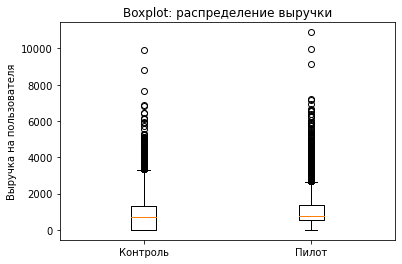

In [431]:
# Boxplot - отрисуем структуру данных, для большей наглядности
data_to_plot = [df_control, df_pilot]
plt.boxplot(data_to_plot, labels=['Контроль', 'Пилот'])
plt.ylabel('Выручка на пользователя')
plt.title('Boxplot: распределение выручки')
plt.show()

In [432]:
# проведем ttest только на реальных покупателях (без нулей)
df_control_buyers = df_control[df_control > 0]
df_pilot_buyers = df_pilot[df_pilot > 0]

stat, pval_buyers = stats.ttest_ind(df_control_buyers, df_pilot_buyers)
print(f"T-тест только на покупателях:")
print(f"p-value = {pval_buyers}")
print(f"Среднее в контроле (покупатели): {df_control_buyers.mean():.2f}")
print(f"Среднее в пилоте (покупатели): {df_pilot_buyers.mean():.2f}")

# проверим разницу в вероятности покупки
conversion_control = (df_control > 0).mean()
conversion_pilot = (df_pilot > 0).mean()
print(f"\nВероятность покупки:")
print(f"Контроль: {conversion_control:.2%}")
print(f"Пилот: {conversion_pilot:.2%}")

T-тест только на покупателях:
p-value = 0.22621844319212428
Среднее в контроле (покупатели): 1222.23
Среднее в пилоте (покупатели): 1237.29

Вероятность покупки:
Контроль: 70.52%
Пилот: 76.96%


Визуально видно, что медианное значение не стало значительно лучше. Но в пилотной группе стало значительно меньше клиентов с 0 покупками, поэтому среднее по пилоту лучше. Вывод:

1) Пилот НЕ увеличивает сумму покупки - покупатели тратят столько же

2) Пилот УВЕЛИЧИВАЕТ конверсию - больше пользователей совершают покупку

**Итог:** 

Гипотеза о том, что новый дизайн увеличит среднюю выручку, ПОДТВЕРДИЛАСЬ. Однако средняя выручка растет не за счет роста среднего чека, а за счет повышения конверсии (вероятность покупки) с 70.5% до 77% (+6.5 п.п.). Эффект достигнут за счет вовлечения большего числа пользователей в покупку, а не за счет увеличения суммы их корзины.

Новый дизайн статистически значимо увеличил среднюю выручку на пользователя. Полученный эффект подтверждается t-тестом, тестом Манна-Уитни и bootstrap-доверительными интервалами. Размер выборки оказался достаточен для обнаруженного эффекта, поэтому эксперимент можно считать успешным и рекомендовать внедрение нового дизайна.